# 03 — Model Training
### Diabetic Retinopathy Detection | APTOS 2019

**Goal:** Train VGG16 with transfer learning to classify DR severity.  
We will:
1. Build the VGG16 model with a custom head
2. Understand the freeze/unfreeze strategy visually
3. Set up optimizer with two learning rate groups
4. Run the full training loop with live metrics
5. Plot training curves
6. Save the best checkpoint

## 0. Imports & Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.config   import Config
from utils.dataset  import set_seed, RetinopathyDataset, get_transforms, get_weighted_sampler
from utils.metrics  import evaluate
from models.vgg16_model import VGG16Retinopathy
from torch.utils.data   import DataLoader

set_seed()
os.makedirs("outputs", exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA L4
VRAM   : 23.9 GB


## 1. Load Data Splits

In [2]:
# Load the splits saved by 02_preprocess.ipynb
train_df = pd.read_csv("outputs/train_split.csv")
val_df   = pd.read_csv("outputs/val_split.csv")

print(f"Train : {len(train_df)} images")
print(f"Val   : {len(val_df)} images")

train_tf, val_tf = get_transforms()

train_dataset = RetinopathyDataset(train_df, Config.TRAIN_IMGS, train_tf)
val_dataset   = RetinopathyDataset(val_df,   Config.TRAIN_IMGS, val_tf)

sampler = get_weighted_sampler(train_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    sampler=sampler,
    num_workers=Config.NUM_WORKERS,
    pin_memory=(DEVICE == "cuda")
)
val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=(DEVICE == "cuda")
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train : 1486 images
Val   : 372 images
Train batches : 47
Val batches   : 12


## 2. Build Model

### Transfer Learning Strategy

```
VGG16 Feature Extractor
─────────────────────────────────────────────────────────
Block 1 (layers 0-4)  : edges, corners          → FROZEN
Block 2 (layers 5-9)  : textures, gradients     → FROZEN
Block 3 (layers 10-16): patterns, simple shapes → FROZEN
Block 4 (layers 17-23): complex shapes          → FROZEN
Block 5 (layers 24-30): high-level features     → FROZEN → UNFROZEN @ epoch 6
─────────────────────────────────────────────────────────
Custom Head
  FC(25088→4096) → ReLU → Dropout(0.5)          → TRAINABLE
  FC(4096→1024)  → ReLU → Dropout(0.5)          → TRAINABLE
  FC(1024→5)                                     → TRAINABLE
```

**Why this schedule?**  
- Early epochs: only the head trains — learns to map VGG features to DR grades  
- After epoch 5: Block 5 unfreezes — fine-tunes high-level features for retinopathy-specific patterns (microaneurysms, haemorrhages)

In [3]:
model = VGG16Retinopathy(
    num_classes=Config.NUM_CLASSES,
    dropout=Config.DROPOUT
).to(DEVICE)

print("Model parameter summary (before unfreeze):")
model.param_summary()
print()

print("Layer-wise trainable status:")
print(f"  {'Layer':<40} {'Trainable':>10}")
print("  " + "-" * 52)
for name, param in model.named_parameters():
    status = "YES" if param.requires_grad else "frozen"
    print(f"  {name:<40} {status:>10}")

Model parameter summary (before unfreeze):
  Total params     :   66,161,477
  Trainable params :   58,526,213
  Frozen params    :    7,635,264

Layer-wise trainable status:
  Layer                                     Trainable
  ----------------------------------------------------
  features.0.weight                            frozen
  features.0.bias                              frozen
  features.2.weight                            frozen
  features.2.bias                              frozen
  features.5.weight                            frozen
  features.5.bias                              frozen
  features.7.weight                            frozen
  features.7.bias                              frozen
  features.10.weight                           frozen
  features.10.bias                             frozen
  features.12.weight                           frozen
  features.12.bias                             frozen
  features.14.weight                           frozen
  features.14.

## 3. Loss, Optimizer & Scheduler

In [4]:
criterion = nn.CrossEntropyLoss()

# 3 param groups with different LRs:
#   Block 5 conv  → low LR  (pretrained, fine-tuning)
#   bridge layers → mid LR  (new, but simple BN+Dropout)
#   classifier    → high LR (new, training from scratch)
optimizer = optim.Adam([
    {"params": model.features[24:].parameters(), "lr": Config.LR_BACKBONE},
    {"params": model.bridge.parameters(),        "lr": Config.LR},
    {"params": model.classifier.parameters(),    "lr": Config.LR},
], weight_decay=Config.WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

print("Criterion : CrossEntropyLoss")
print("Optimizer : Adam with 3 param groups")
print(f"  Block 5 LR    : {Config.LR_BACKBONE}")
print(f"  Bridge LR     : {Config.LR}")
print(f"  Classifier LR : {Config.LR}")

Criterion : CrossEntropyLoss
Optimizer : Adam with 3 param groups
  Block 5 LR    : 1e-05
  Bridge LR     : 0.0001
  Classifier LR : 0.0001


## 4. Training Loop

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total

In [6]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "val_kappa":  []
}

best_kappa = -1.0
best_epoch =  0

print("=" * 70)
print(f"{'Epoch':>6} | {'T-Loss':>8} {'T-Acc':>7} | {'V-Loss':>8} {'V-Acc':>7} {'Kappa':>7}")
print("=" * 70)

for epoch in range(1, Config.NUM_EPOCHS + 1):
    # ── Train & evaluate ───────────────────────────────────────
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_acc, val_kappa, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step(val_loss)

    # ── Record history ─────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_kappa"].append(val_kappa)

    # ── Save best model ────────────────────────────────────────
    is_best = val_kappa > best_kappa
    if is_best:
        best_kappa = val_kappa
        best_epoch = epoch
        torch.save(model.state_dict(), Config.SAVE_PATH)

    marker = " ◀ best" if is_best else ""
    print(
        f"{epoch:>6} | {train_loss:>8.4f} {train_acc:>7.4f} | "
        f"{val_loss:>8.4f} {val_acc:>7.4f} {val_kappa:>7.4f}{marker}"
    )

print("=" * 70)
print(f"\nBest → Epoch {best_epoch} | Quadratic Kappa = {best_kappa:.4f}")
print(f"Saved → {Config.SAVE_PATH}")

 Epoch |   T-Loss   T-Acc |   V-Loss   V-Acc   Kappa
     1 |   1.2415  0.4946 |   1.0056  0.5914  0.7228 ◀ best
     2 |   1.0436  0.5666 |   0.9007  0.6478  0.7695 ◀ best
     3 |   0.9970  0.5915 |   0.8953  0.6694  0.7730 ◀ best
     4 |   0.9031  0.6332 |   0.9125  0.6344  0.7786 ◀ best
     5 |   0.8433  0.6555 |   0.9256  0.6425  0.7576
     6 |   0.8503  0.6595 |   0.9332  0.6156  0.7790 ◀ best
     7 |   0.7862  0.6958 |   0.9217  0.6210  0.7014
     8 |   0.7838  0.6817 |   0.9522  0.6156  0.7250
     9 |   0.7603  0.6978 |   0.9188  0.6532  0.7545
    10 |   0.7653  0.6911 |   1.0218  0.6048  0.7113
    11 |   0.7337  0.7153 |   0.9786  0.6237  0.7450
    12 |   0.7036  0.7133 |   0.9152  0.6532  0.7918 ◀ best
    13 |   0.6798  0.7248 |   0.9340  0.6263  0.7348
    14 |   0.6600  0.7416 |   0.8957  0.6667  0.7934 ◀ best
    15 |   0.7073  0.7073 |   0.9250  0.6667  0.7873
    16 |   0.6806  0.7315 |   0.9280  0.6720  0.8022 ◀ best
    17 |   0.6757  0.7396 |   0.8594  0.685

## 5. Training Curves

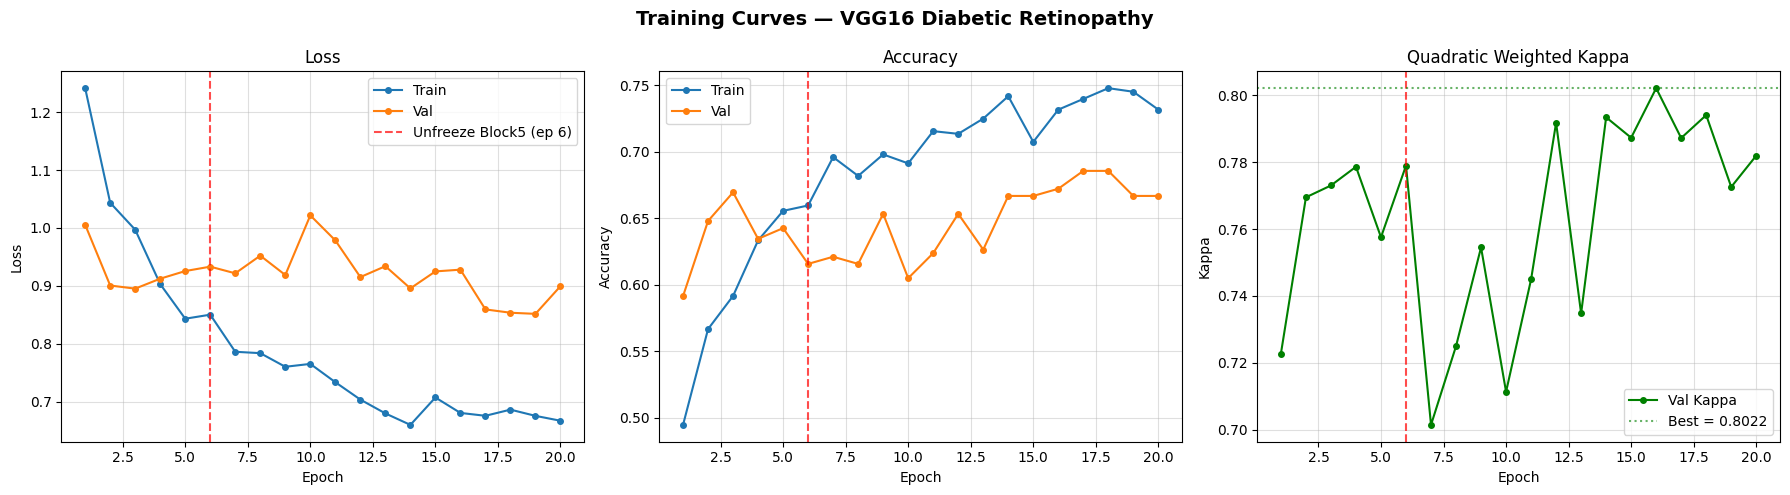

Saved: outputs/03_training_curves.png


In [7]:
epochs = range(1, Config.NUM_EPOCHS + 1)
unfreeze_x = Config.UNFREEZE_EPOCH + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Curves — VGG16 Diabetic Retinopathy",
             fontsize=14, fontweight="bold")

# ── Loss ──
axes[0].plot(epochs, history["train_loss"], label="Train", marker="o", markersize=4)
axes[0].plot(epochs, history["val_loss"],   label="Val",   marker="o", markersize=4)
axes[0].axvline(unfreeze_x, color="red", linestyle="--",
                alpha=0.7, label=f"Unfreeze Block5 (ep {unfreeze_x})")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# ── Accuracy ──
axes[1].plot(epochs, history["train_acc"], label="Train", marker="o", markersize=4)
axes[1].plot(epochs, history["val_acc"],   label="Val",   marker="o", markersize=4)
axes[1].axvline(unfreeze_x, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# ── Kappa ──
axes[2].plot(epochs, history["val_kappa"],
             label="Val Kappa", marker="o", markersize=4, color="green")
axes[2].axvline(unfreeze_x, color="red", linestyle="--", alpha=0.7)
axes[2].axhline(best_kappa, color="green", linestyle=":",
                alpha=0.6, label=f"Best = {best_kappa:.4f}")
axes[2].set_title("Quadratic Weighted Kappa")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Kappa")
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/03_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_training_curves.png")

---
## 6. Save Training History

In [8]:
history_df = pd.DataFrame({
    "epoch":      list(epochs),
    "train_loss": history["train_loss"],
    "val_loss":   history["val_loss"],
    "train_acc":  history["train_acc"],
    "val_acc":    history["val_acc"],
    "val_kappa":  history["val_kappa"],
})

history_df.to_csv("outputs/03_training_history.csv", index=False)
print("Saved: outputs/03_training_history.csv")
print()
print(history_df.to_string(index=False))

Saved: outputs/03_training_history.csv

 epoch  train_loss  val_loss  train_acc  val_acc  val_kappa
     1    1.241504  1.005615   0.494616 0.591398   0.722781
     2    1.043614  0.900683   0.566622 0.647849   0.769509
     3    0.997011  0.895274   0.591521 0.669355   0.773050
     4    0.903109  0.912480   0.633244 0.634409   0.778647
     5    0.843317  0.925631   0.655451 0.642473   0.757572
     6    0.850305  0.933238   0.659489 0.615591   0.778989
     7    0.786216  0.921726   0.695828 0.620968   0.701444
     8    0.783836  0.952248   0.681696 0.615591   0.725000
     9    0.760300  0.918807   0.697847 0.653226   0.754523
    10    0.765281  1.021794   0.691117 0.604839   0.711337
    11    0.733669  0.978557   0.715343 0.623656   0.744962
    12    0.703647  0.915233   0.713324 0.653226   0.791818
    13    0.679773  0.934018   0.724764 0.626344   0.734774
    14    0.659953  0.895712   0.741588 0.666667   0.793440
    15    0.707263  0.925037   0.707268 0.666667   0.787331


---
## 7. Summary

In [10]:
total, trainable_head, _ = model.count_params()

print("=" * 55)
print("  TRAINING SUMMARY")
print("=" * 55)
print(f"  Model         : VGG16 (ImageNet pretrained)")
print(f"  Total params  : {total:,}")
print(f"  Epochs        : {Config.NUM_EPOCHS}")
print(f"  Unfreeze at   : Epoch {Config.UNFREEZE_EPOCH + 1}")
print(f"  Best epoch    : {best_epoch}")
print(f"  Best kappa    : {best_kappa:.4f}")
print(f"  Checkpoint    : {Config.SAVE_PATH}")
print()
print("  Saved outputs:")
print("    outputs/best_model.pth")
print("    outputs/03_training_curves.png")
print("    outputs/03_training_history.csv")
print("=" * 55)

  TRAINING SUMMARY
  Model         : VGG16 (ImageNet pretrained)
  Total params  : 66,161,477
  Epochs        : 20
  Unfreeze at   : Epoch 6
  Best epoch    : 16
  Best kappa    : 0.8022
  Checkpoint    : /teamspace/studios/this_studio/diabetic-retinopathy/outputs/best_model.pth

  Saved outputs:
    outputs/best_model.pth
    outputs/03_training_curves.png
    outputs/03_training_history.csv
